In [1]:
# Import required libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

from config.config import *
import src.utils as ut

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load train, test datasets
train_dataset = ut.SeismicDataset(data_path=Path("../data/processed/signals_train.hdf5"))
test_dataset = ut.SeismicDataset(data_path=Path("../data/processed/signals_test.hdf5"))

print(f"\n✓ Datasets loaded successfully")
print(f"  Train: {len(train_dataset)} signals")
print(f"  Test: {len(test_dataset)} signals")
print(f"\nSample (signal, label, magnitude): {train_dataset[0]}")


✓ Datasets loaded successfully
  Train: 135 signals
  Test: 36 signals

Sample (signal, label, magnitude): (array([  -124.60970609,    -86.57610512,    -46.54250415, ...,
       -10521.03606728,  -4428.00246631,   9053.03113466]), 1, 4.4)


Unitary test

In [3]:
from src.utils import compute_persistence, takens_embedding

signal0, label0, mag0 = train_dataset[0]
print(f"Signal shape: {signal0.shape}, Label: {label0}, Magnitude: {mag0}")
print(f"Signal stats ; Mean: {np.mean(signal0)}, Std: {np.std(signal0)}, Min: {np.min(signal0)}, Max: {np.max(signal0)}")

Signal shape: (2520,), Label: 1, Magnitude: 4.4
Signal stats ; Mean: -1.1837867546885733e-13, Std: 11532.14368411183, Min: -89180.38874068836, Max: 78806.71206221846


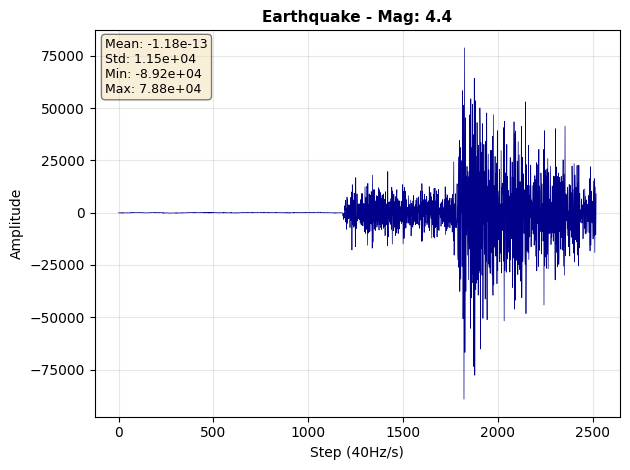

In [4]:
ut.plot_waveform(signal=signal0, label='Earthquake', mag=mag0)

(feature, frames) = (n_mfcc + n_mfcc + n_mfcc, hop_length)

(60, 313)


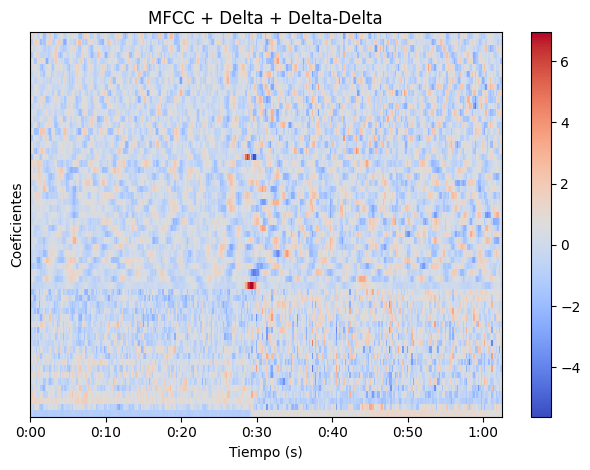

In [5]:
import librosa

sr = 40.0  # Sample rate
win_length = int(0.6*sr) # 600ms
hop_length = max(1, int(0.2*sr)) # 200ms, ensure at least 1

x = signal0.astype(np.float32).copy()  # Convert to floating-point
mfcc = librosa.feature.mfcc(y = x, sr=sr, n_mfcc=60, hop_length=hop_length, n_fft=win_length, n_mels=20, dct_type=2, norm='ortho', center=False)
mfcc_delta = librosa.feature.delta(mfcc, mode='mirror', order=1)
mfcc_delta_delta = librosa.feature.delta(mfcc, mode='mirror', order=2)
mfcc_combined = np.concatenate((mfcc, mfcc_delta, mfcc_delta_delta), axis=0)
mfcc_combined_norm = (mfcc_combined - np.mean(mfcc_combined, axis=1, keepdims=True)) / np.std(mfcc_combined, axis=1, keepdims=True)
print(mfcc_combined_norm.shape)
librosa.display.specshow(mfcc_combined_norm, x_axis='time', sr=sr, hop_length=hop_length);
plt.xlabel('Tiempo (s)')
plt.ylabel('Coeficientes')
plt.title('MFCC + Delta + Delta-Delta')
plt.colorbar()
plt.tight_layout()
plt.show()

In [6]:
pc = mfcc_combined_norm.T
print(pc.shape)

(313, 60)


In [7]:
print(f"PC stats ; Mean: {np.mean(pc)}, Std: {np.std(pc)}, Min: {np.min(pc)}, Max: {np.max(pc)}")

PC stats ; Mean: -2.7929758505962354e-10, Std: 1.0, Min: -5.607261657714844, Max: 6.937909126281738


dim = 120
seq_len = 14 ~ tamanio de la senial

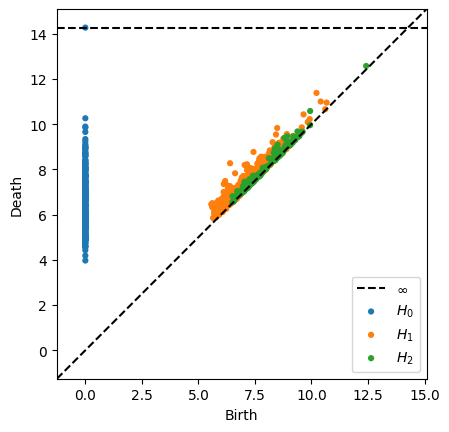

In [8]:
from persim import plot_diagrams
diagram0 = compute_persistence(pc, maxdim=2)
plot_diagrams(diagram0, show=True)